In [1]:
import pandas as pd
from lightgbm import LGBMClassifier, early_stopping
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import f1_score, precision_score, recall_score, precision_recall_curve, make_scorer, average_precision_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTENC
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('cleaneddata_metrics.csv')
df.head()

,Unnamed: 0.1,Unnamed: 0,event_id,ad_id,user_id,timestamp,day_of_week,time_of_day,event_type,ad_id:1,...,user_age,age_group,country,location,interests,purchase,eq_budget,w_ctr,w_cr,w_cpa
0,0,0,1,197,2359b,2025-07-26 00:19:56,saturday,night,like,197,...,24,18-24,united states,west shawna,"gaming, food",0,6682.34,12.71,6.05,514.03
1,1,1,2,51,f9c67,2025-06-15 08:28:07,sunday,morning,share,51,...,30,25-34,united states,meyersland,"photography, finance",0,14846.29,10.76,7.45,1060.45
2,2,2,3,46,5b868,2025-06-27 00:40:02,friday,night,impression,46,...,20,18-24,united states,barrerahaven,"fashion, sports, travel",0,4917.32,10.49,7.95,351.24
3,3,3,4,166,3d440,2025-06-05 19:20:45,thursday,evening,impression,166,...,18,18-24,united states,lake angelaland,"food, art",0,19924.97,11.83,3.54,2846.42
4,4,4,5,52,68f1a,2025-07-22 08:30:29,tuesday,morning,impression,52,...,58,55-65,united kingdom,robinsonberg,"finance, lifestyle",0,26447.47,11.49,4.06,3305.93


**Target Variable (Y) & Features (X) Chosen**

Y: Conversion (Purchase) or not

X: 4 Categorical Features (Age_Group, Country, Advertisement Type, Day of Week) + 
   3 Numerical Features: CTR, CR and CPA

**Model 2: Light Gradient Booster Model (Light GBM)**

1) Light GBM model chosen due to categorical target variable (Purchase or Not)
2) Class weighting applies due to imbalanced class size (0.5% conversion rate)

In [3]:
# Define features (X)
num_features = ["w_ctr","w_cpa"]
cat_features = ["age_group","country","ad_type","day_of_week"]

# Convert Categorical columns into Category Datatype
for col in cat_features:
    df[col] = df[col].astype("category")

# Define X & Y 
X = df[num_features + cat_features]
Y = df["purchase"]

# Train/Test Split (70% train, 30% test)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42, stratify=Y)

# Calculate scale_pos_weight (negatives / positives)
scale_pos_weight = len(Y_train[Y_train == 0]) / len(Y_train[Y_train == 1])

# Define Model
model = LGBMClassifier(
    objective="binary",
    boosting_type="gbdt",
    scale_pos_weight=scale_pos_weight,
    class_weight="balanced",       # handles class imbalance
    learning_rate=0.05,
    num_leaves=150,
    max_depth=1,
    n_estimators=5000)

# Train with Early Stopping
model.fit(
    X_train, Y_train,
    eval_set=[(X_test, Y_test)],
    eval_metric=["binary_logloss", "auc", "average_precision"],
    callbacks=[early_stopping(100)],
    categorical_feature=cat_features)

# Predictions (probabilities)
Y_pred_prob = model.predict_proba(X_test)[:, 1]
Y_pred_prob

[LightGBM] [Info] Number of positive: 1422, number of negative: 278578
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007906 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 348
[LightGBM] [Info] Number of data points in the train set: 280000, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

array([0.52472916, 0.52472916, 0.52472916, ..., 0.52472916, 0.52472916,
       0.52472916], shape=(120000,))

**Finding**

1) The purchase probabilities are higher at 0.52 as compared to 0.44 of Logistic Regression (model 1)

**Light GBM Model 2 Performance Evaluation**

In [4]:
# Tune threshold for best F1
precision, recall, thresholds = precision_recall_curve(Y_test, Y_pred_prob)
f1_scores = 2 * (precision * recall) / (precision + recall)
best_threshold = thresholds[f1_scores.argmax()]

# Apply best threshold
Y_pred_labels = (Y_pred_prob >= best_threshold).astype(int)
Y_pred_prob

print("Best Threshold:", round(best_threshold,2))
print("F1:", round(f1_score(Y_test, Y_pred_labels),2))
print("Precision:", round(precision_score(Y_test, Y_pred_labels),2))
print("Recall:", round(recall_score(Y_test, Y_pred_labels),2))

Best Threshold: 0.52
F1: 0.01
Precision: 0.01
Recall: 1.0


**Findings**

1) Much higher recall score of 0.99 as compared to logistic regression model
2) But lower precision score of 0.01 as compared to model 1, hence resultin in low F1 score of 0.01

**Model 2 Confusion Matrix**

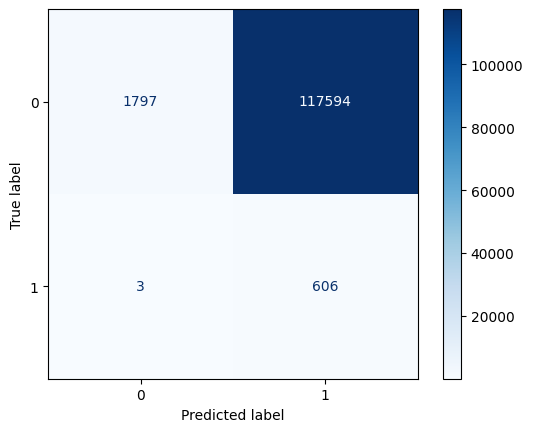

In [5]:
# Predictions (using your tuned threshold)
Y_pred_labels = (Y_pred_prob >= best_threshold).astype(int)

# Compute confusion matrix
cm = confusion_matrix(Y_test, Y_pred_labels, labels=[0,1])

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
disp.plot(cmap="Blues", values_format="d")

**Features Importance**

       Feature  Importance
1        w_cpa           1
0        w_ctr           0
2    age_group           0
3      country           0
4      ad_type           0
5  day_of_week           0


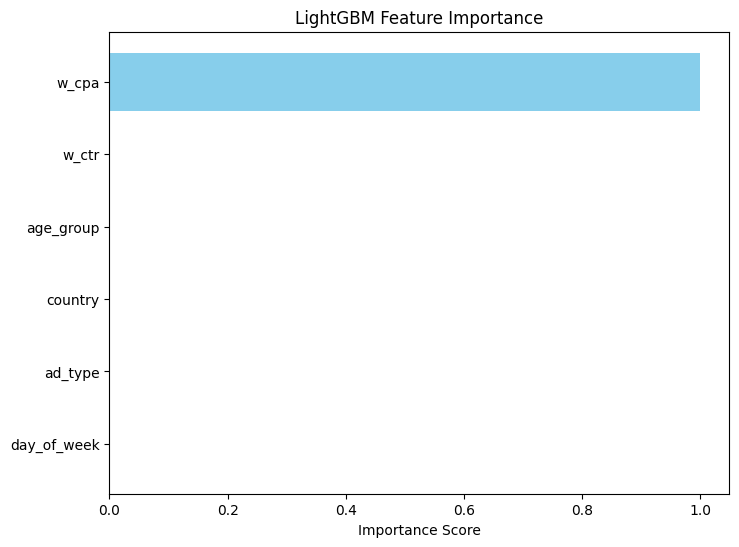

In [6]:
# Get feature importances
importances = model.feature_importances_
feature_names = model.feature_name_

# Create DataFrame
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Display table
print(importance_df)

# Plot feature importance
plt.figure(figsize=(8,6))
plt.barh(importance_df["Feature"], importance_df["Importance"], color="skyblue")
plt.gca().invert_yaxis()
plt.title("LightGBM Feature Importance")
plt.xlabel("Importance Score")
plt.show()

**Finding**
1) only CPA is relevant feature for the model

**Feature Engineering (adding 1 interactive feature)**

In [7]:
# Create Interaction Feature (County x Ad_type)
df["CTR/CPA"] = df["w_ctr"] / df["w_cpa"].astype(float)
df["CTR/CPA"] = df["CTR/CPA"].astype("float")

# Define features (X2)
num_features = ["w_ctr","w_cpa", "CTR/CPA"]
cat_features = ["age_group","country","ad_type","day_of_week"]

# Convert Categorical columns into Category Datatype
for col in cat_features:
    df[col] = df[col].astype("category")

# Define X2 & Y2 
X2 = df[num_features + cat_features]
Y2 = df["purchase"]

# Train/Test Split (70% train, 30% test)
X2_train, X2_test, Y2_train, Y2_test = train_test_split(X2, Y2, test_size=0.3, random_state=42, stratify=Y)

# Calculate scale_pos_weight (negatives / positives)
scale_pos_weight = len(Y2_train[Y2_train == 0]) / len(Y2_train[Y2_train == 1])*2

# Define Model
model = LGBMClassifier(
    objective="binary",
    boosting_type="gbdt",
    scale_pos_weight=scale_pos_weight,
    class_weight="balanced",       # handles class imbalance
    learning_rate=0.05,
    min_data_in_leaf=2,
    num_leaves=225,
    max_depth=20,
    n_estimators=5000)

# Train with Early Stopping
model.fit(
    X2_train, Y2_train,
    eval_set=[(X2_test, Y2_test)],
    eval_metric=["binary_logloss", "auc", "average_precision"],
    callbacks=[early_stopping(100)],
    categorical_feature=cat_features)

# Predictions (probabilities)
Y2_pred_prob = model.predict_proba(X2_test)[:, 1]
Y2_pred_prob

[LightGBM] [Warning] min_data_in_leaf is set=2, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=2
[LightGBM] [Warning] min_data_in_leaf is set=2, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=2
[LightGBM] [Info] Number of positive: 1422, number of negative: 278578
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004627 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 549
[LightGBM] [Info] Number of data points in the train set: 280000, number of used features: 7
[LightGBM] [Warning] min_data_in_leaf is set=2, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training

array([0.52478228, 0.52490191, 0.52484572, ..., 0.52487291, 0.52489439,
       0.52485242], shape=(120000,))

In [8]:
# Tune threshold for best F1
# precision, recall, thresholds = precision_recall_curve(Y2_test, Y2_pred_prob)
avg_precision = average_precision_score(Y2_test, Y2_pred_prob)
f1_scores = 2 * (precision * recall) / (precision + recall)
best_threshold = thresholds[f1_scores.argmax()]

# Apply best threshold
Y2_pred_labels = (Y2_pred_prob >= best_threshold).astype(int)
Y2_pred_prob

print("Best Threshold:", round(best_threshold,2))
print("F1:", round(f1_score(Y2_test, Y2_pred_labels),2))
print("Avg Precision:", round(average_precision_score(Y2_test, Y2_pred_labels),2))
print("Recall:", round(recall_score(Y2_test, Y2_pred_labels),2))

Best Threshold: 0.52
F1: 0.01
Avg Precision: 0.01
Recall: 0.96


**Findings**
1) Adding 1 interactive feature & tuning parameters did not change the precision and f1 scores.